<h1> Import Necessary Libraries </h1>

In [99]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from retinaface import RetinaFace
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
scaler = GradScaler()

/tmp/ipykernel_5729/3522360610.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
print(torch.cuda.is_available())

True


<h1> Config </h1>

In [102]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
UPSCALE = 4
EPOCHS = 25
LR = 1e-4
BATCH_SIZE = 2
IMAGE_SIZE = 96

<h1> Dataset Loading and Preprocessing </h1>

In [ ]:
class SRDataset(Dataset):
    def __init__(self, path, limit=2000):
        self.paths = [os.path.join(path, x) for x in os.listdir(path)][:limit]

        self.hr = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

        self.lr = transforms.Compose([
            transforms.Resize((IMAGE_SIZE//UPSCALE, IMAGE_SIZE//UPSCALE)),
            transforms.ToTensor()
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.lr(img), self.hr(img)

<h1> Generator </h1>

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c, c, 3, 1, 1),
            nn.BatchNorm2d(c),
            nn.PReLU(),
            nn.Conv2d(c, c, 3, 1, 1),
            nn.BatchNorm2d(c)
        )
    def forward(self, x): return x + self.block(x)

In [ ]:
class ResidualDenseBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, channels, 3, 1, 1)
        self.conv2 = nn.Conv2d(channels, channels, 3, 1, 1)
        self.conv3 = nn.Conv2d(channels, channels, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        out = self.lrelu(self.conv1(x))
        out = self.lrelu(self.conv2(out))
        out = self.conv3(out)
        return x + 0.2 * out

In [ ]:
class RRDB(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(channels)
        self.rdb2 = ResidualDenseBlock(channels)
        self.rdb3 = ResidualDenseBlock(channels)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return x + 0.2 * out

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_first = nn.Conv2d(3, 64, 3, 1, 1)

        self.body = nn.Sequential(*[RRDB(64) for _ in range(5)])

        self.conv_body = nn.Conv2d(64, 64, 3, 1, 1)

        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2),
        )

        self.conv_last = nn.Conv2d(64, 3, 3, 1, 1)

    def forward(self, x):
        fea = self.conv_first(x)

        body = self.body(fea)
        body = self.conv_body(body)
        fea = fea + body

        out = self.upsample(fea)
        out = self.conv_last(out)

        return torch.tanh(out)

<h1> Discriminator </h1>

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, stride):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride, 1),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.net = nn.Sequential(
            block(3, 64, 1),
            block(64, 64, 2),
            block(64, 128, 1),
            block(128, 128, 2),
            block(128, 256, 1),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

<h1> Loss function

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features[:16]
        self.vgg = vgg.eval()
        for p in self.vgg.parameters():
            p.requires_grad = False

        self.criterion = nn.L1Loss()

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return self.criterion(sr_feat, hr_feat)

<h1> Checkpointing </h1>


In [ ]:
class ModelCheckpointManager:
    def __init__(self, save_path, lambda_p=0.01):
        self.best_score = -1e9
        self.save_path = save_path
        self.lambda_p = lambda_p
        self.perceptual = VGGPerceptualLoss().to(DEVICE)

    def to_img(self, x):
        x = x.detach().cpu()
        if x.dim() == 4:
            x = x[0]
        x = x.permute(1, 2, 0).numpy()
        return np.clip(x, 0, 1)

    def evaluate(self, model, lr, hr):

        model.eval()

        with torch.no_grad():
            sr = model(lr)

        sr_img = self.to_img(sr)
        hr_img = self.to_img(hr)

        ssim_val = ssim(
            hr_img,
            sr_img,
            channel_axis=2,
            data_range=1.0
        )

        sr_vgg = sr
        hr_vgg = hr

        if sr_vgg.dim() == 3:
            sr_vgg = sr_vgg.unsqueeze(0)
        if hr_vgg.dim() == 3:
            hr_vgg = hr_vgg.unsqueeze(0)

        sr_vgg = sr_vgg.to(DEVICE)
        hr_vgg = hr_vgg.to(DEVICE)

        p_loss = self.perceptual(sr_vgg, hr_vgg).item()

        score = ssim_val - self.lambda_p * p_loss

        return score, ssim_val, p_loss

    def step(self, model, lr, hr, epoch):

        score, ssim_val, p_loss = self.evaluate(model, lr, hr)

        print(f"\n📊 Epoch {epoch}")
        print(f"SSIM: {ssim_val:.4f}")
        print(f"Perceptual Loss: {p_loss:.4f}")
        print(f"Final Score: {score:.4f}")

        if score > self.best_score:
            self.best_score = score
            torch.save(model.state_dict(), self.save_path)
            print(f" New BEST model saved at {self.save_path}")

        return score

<h1> Training Loop </h1>

In [ ]:
scaler_g = GradScaler()
scaler_d = GradScaler()


def train_model(path, model_type="face"):

    dataset = SRDataset(path)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    gen = Generator().to(DEVICE)
    disc = Discriminator().to(DEVICE)

    opt_g = optim.Adam(gen.parameters(), lr=LR)
    opt_d = optim.Adam(disc.parameters(), lr=LR)

    bce = nn.BCEWithLogitsLoss()
    l1 = nn.L1Loss()
    perc = VGGPerceptualLoss().to(DEVICE)

    if model_type == "face":
        ckpt = ModelCheckpointManager("/content/best_face_model.pth")
    else:
        ckpt = ModelCheckpointManager("/content/best_scene_model.pth")

    for epoch in range(EPOCHS):

        gen.train()
        disc.train()

        loop = tqdm(loader)

        for lr_img, hr_img in loop:

            lr_img = lr_img.to(DEVICE, non_blocking=True)
            hr_img = hr_img.to(DEVICE, non_blocking=True)

            with autocast():
                with torch.no_grad():
                    fake = gen(lr_img)

                real_out = disc(hr_img)
                fake_out = disc(fake)

                loss_d = (
                    bce(real_out, torch.ones_like(real_out)) +
                    bce(fake_out, torch.zeros_like(fake_out))
                )

            opt_d.zero_grad()
            scaler_d.scale(loss_d).backward()
            scaler_d.step(opt_d)
            scaler_d.update()

            with autocast():

                fake = gen(lr_img)
                fake_out = disc(fake)

                loss_g = (
                    1.0 * l1(fake, hr_img) +
                    0.01 * perc(fake, hr_img) +
                    0.001 * bce(fake_out, torch.ones_like(fake_out))
                )

            opt_g.zero_grad()
            scaler_g.scale(loss_g).backward()
            scaler_g.step(opt_g)
            scaler_g.update()

            loop.set_description(
                f"[{model_type.upper()}] Epoch {epoch+1}/{EPOCHS} "
                f"D:{loss_d.item():.4f} G:{loss_g.item():.4f}"
            )

        sample_lr, sample_hr = next(iter(loader))

        sample_lr = sample_lr.to(DEVICE)
        sample_hr = sample_hr.to(DEVICE)

        ckpt.step(gen, sample_lr, sample_hr, epoch)

    return gen

/tmp/ipykernel_5729/3715290849.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler()
/tmp/ipykernel_5729/3715290849.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler()


<h1> Train

In [103]:

face_model = train_model(
    "data/celeba/img_align_celeba/img_align_celeba",
    model_type="face"
)

scene_model = train_model(
    "data/div2k/DIV2K_train_HR",
    model_type="scene"
)



[FACE] Epoch 1/25 D:0.8821 G:0.0493: 100%|██████████| 1000/1000 [00:49<00:00, 20.07it/s]



📊 Epoch 0
SSIM: 0.7993
Perceptual Loss: 0.7065
Final Score: 0.7923
🔥 New BEST model saved at /content/best_face_model.pth


[FACE] Epoch 2/25 D:0.0709 G:0.0395: 100%|██████████| 1000/1000 [00:50<00:00, 19.80it/s]



📊 Epoch 1
SSIM: 0.7866
Perceptual Loss: 0.7505
Final Score: 0.7791


[FACE] Epoch 3/25 D:0.0516 G:0.0435: 100%|██████████| 1000/1000 [00:50<00:00, 19.87it/s]


...


📊 Epoch 22
SSIM: 0.6856
Perceptual Loss: 0.9887
Final Score: 0.6757


[SCENE] Epoch 24/25 D:0.0994 G:0.0630: 100%|██████████| 400/400 [01:32<00:00,  4.31it/s]



📊 Epoch 23
SSIM: 0.7973
Perceptual Loss: 0.8399
Final Score: 0.7889


[SCENE] Epoch 25/25 D:1.0113 G:0.0553: 100%|██████████| 400/400 [01:33<00:00,  4.30it/s]



📊 Epoch 24
SSIM: 0.6045
Perceptual Loss: 0.9067
Final Score: 0.5955


<h1> Save Models

In [106]:
torch.save(scene_model.state_dict(), "/content/drive/MyDrive/scene_srgan.pth")
torch.save(face_model.state_dict(), "/content/drive/MyDrive/face_srgan.pth")

<h1> Output and Evaluation


In [95]:
def hybrid_infer(face_model, scene_model, img_path):

    torch.cuda.empty_cache()

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0

    h, w, _ = img.shape

    lr_tensor = transforms.ToTensor()(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        scene_out = scene_model(lr_tensor)

    scene_out = scene_out.squeeze(0).cpu().permute(1, 2, 0).numpy()
    scene_out = np.clip(scene_out, 0, 1)
    scene_out = cv2.resize(scene_out, (w, h))

    faces = detect_faces((img * 255).astype(np.uint8))

    for (x, y, fw, fh) in faces:

        face = img[y:y+fh, x:x+fw]

        if face.shape[0] < 10 or face.shape[1] < 10:
            continue

        face_resized = cv2.resize(face, (128, 128))
        ft = transforms.ToTensor()(face_resized).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            face_out = face_model(ft)

        face_out = face_out.squeeze(0).cpu().permute(1, 2, 0).numpy()
        face_out = np.clip(face_out, 0, 1)

        face_out = cv2.resize(face_out, (fw, fh))

        mask = create_soft_mask(fh, fw)

        scene_patch = scene_out[y:y+fh, x:x+fw]

        scene_out[y:y+fh, x:x+fw] = (
            mask * face_out +
            (1 - mask) * scene_patch
        )

    return scene_out

In [ ]:
def evaluate(face_model, scene_model, lr_path, hr_path):

    hr = cv2.imread(hr_path)
    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)
    hr = hr.astype(np.float32) / 255.0

    h, w, _ = hr.shape

    sr = hybrid_infer(face_model, scene_model, lr_path)
    sr = np.clip(sr, 0, 1)
    sr = cv2.resize(sr, (w, h))

    psnr_val = psnr(hr, sr, data_range=1.0)

    ssim_val = ssim(
        hr,
        sr,
        channel_axis=2,
        data_range=1.0
    )

    print("\n📊 RESULTS")
    print("------------------")
    print(f"PSNR: {psnr_val:.4f}")
    print(f"SSIM: {ssim_val:.4f}")

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(cv2.imread(lr_path)[..., ::-1])
    plt.title("LR Input")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(sr)
    plt.title("Hybrid SR Output")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(hr)
    plt.title("HR Ground Truth")
    plt.axis("off")

    plt.show()

    return psnr_val, ssim_val, sr

In [137]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# face_model = Generator().to(DEVICE)
# scene_model = Generator().to(DEVICE)

face = Generator().to(DEVICE)
scene = Generator().to(DEVICE)

# face_model.load_state_dict(torch.load("/content/drive/MyDrive/face_srgan_1.pth", map_location=DEVICE))
# scene_model.load_state_dict(torch.load("/content/drive/MyDrive/scene_srgan_1.pth", map_location=DEVICE))

face.load_state_dict(torch.load("/content/best_face_model.pth", map_location=DEVICE))
scene.load_state_dict(torch.load("/content/best_scene_model.pth", map_location=DEVICE))

face_model.eval()
scene_model.eval()

print("Models loaded successfully!")

Models loaded successfully!


In [93]:
def detect_faces(img):
    faces = RetinaFace.detect_faces(img)

    boxes = []
    if isinstance(faces, dict):
        for key in faces:
            x1, y1, x2, y2 = faces[key]["facial_area"]
            boxes.append((x1, y1, x2 - x1, y2 - y1))

    return boxes

In [94]:
def create_soft_mask(h, w):
    y = np.linspace(-1, 1, h)
    x = np.linspace(-1, 1, w)
    xv, yv = np.meshgrid(x, y)

    mask = np.exp(-(xv**2 + yv**2) * 4)
    mask = mask[..., np.newaxis]

    return mask.astype(np.float32)


📊 RESULTS
------------------
PSNR: 36.0203
SSIM: 0.9941


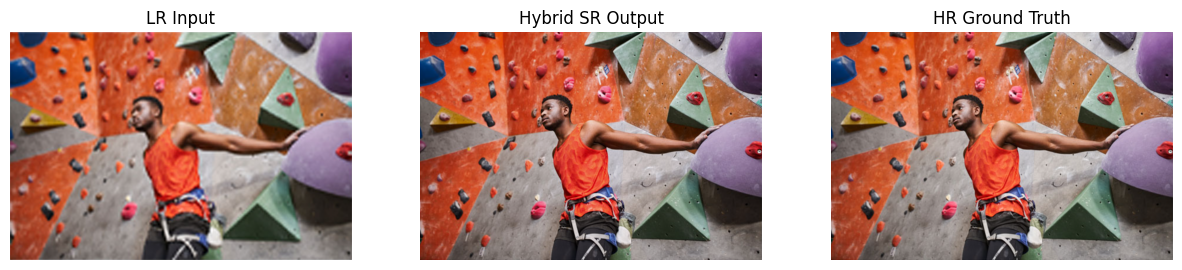

(np.float64(36.02027213302676),
 np.float32(0.99409884),
 array([[[0.4629983 , 0.13938767, 0.11238836],
         [0.51462066, 0.09991185, 0.06294787],
         [0.5765066 , 0.1198631 , 0.0348276 ],
         ...,
         [0.53538024, 0.45398384, 0.5604868 ],
         [0.5265803 , 0.4604121 , 0.54616517],
         [0.62930256, 0.60985136, 0.6505141 ]],
 
        [[0.60484403, 0.11075324, 0.0679006 ],
         [0.635587  , 0.08167466, 0.06211699],
         [0.6387837 , 0.10150592, 0.02851279],
         ...,
         [0.5789194 , 0.49998897, 0.61082655],
         [0.5523535 , 0.47046232, 0.5716162 ],
         [0.64493936, 0.5900932 , 0.66537225]],
 
        [[0.65904385, 0.09561108, 0.04186246],
         [0.7025209 , 0.0689211 , 0.03172621],
         [0.65599084, 0.0876168 , 0.00180737],
         ...,
         [0.6055383 , 0.5072237 , 0.6316258 ],
         [0.56275785, 0.47177   , 0.5881667 ],
         [0.66587573, 0.59627235, 0.6819781 ]],
 
        ...,
 
        [[0.3544923 , 0.1146516

In [139]:
evaluate(
    face,
    scene,
    "/content/LR_test.png",
    "/content/HR_test.png"
)

<h1> Clear GPU caching

In [134]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install scikit-image

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import os

os.makedirs('data', exist_ok=True)
print('Created data directory')

Created data directory


In [ ]:
os.makedirs('data/celeba', exist_ok=True)
os.makedirs('data/div2k', exist_ok=True)
print('Created data/celeba and data/div2k directories')

Created data/celeba and data/div2k directories


In [92]:
!pip install retina-face

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip celeba-dataset.zip -d data/celeba

!wget http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
!unzip DIV2K_train_HR.zip -d data/div2k

Streaming output truncated to the last 5000 lines.
  inflating: data/celeba/img_align_celeba/img_align_celeba/198418.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198419.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198420.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198421.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198422.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198423.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198424.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198425.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198426.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198427.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198428.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198429.jpg  
  inflating: data/celeba/img_align_celeba/img_align_celeba/198430.jpg  
  inflating: 

In [ ]:
!pip install torch torchvision opencv-python pillow tqdm kaggle